# 4C - Sinal pixel-a-pixel: conjunto Pacifico x precipitacao (Brasil -> NEB -> Sul)

**Pergunta especifica.** Quanto tempo demora para o sinal do El Nino (e da La Nina) afetar as chuvas do Brasil? A distribuicao do sinal e feita **pixel-a-pixel** (CHIRPS 0,25 grau) para o **Brasil inteiro** e, em seguida, detalhada em dois recortes: **Nordeste (NEB)** e **Sul**.

**Metodologia.** Chuva CHIRPS somada por semana W-SUN e convertida em anomalia padronizada por pixel (climatologia harmonica de 3 harmonicos, base 1991-2020). Correlacao de Pearson x(t-L) -> chuva(t) por pixel, variavel do conjunto Pacifico e lag semanal (0-78, passo 2); graus de liberdade efetivos de Bretherton por pixel; FDR Benjamini-Hochberg (alfa=0,10) por condicao. Tres condicoes: **todas as semanas**, **semanas El Nino** e **semanas La Nina** (fases ativas do 4A). A organizacao e sempre: Brasil inteiro primeiro, depois o recorte regional com mapas ampliados, tabelas por variavel e distribuicao dos lags.

**Saidas.** `phase4C_atlas_pixel.zarr`, `phase4C_best_lag_pixel.csv`, `phase4C_lag_resposta_neb_sul.csv`, `phase4C_mapas_brasil.png`, `phase4C_recorte_NEB.png`, `phase4C_recorte_SUL.png`, `phase4C_lags_neb_sul.png`.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase4_utils as u

Z, px = u.build_chirps_weekly_zanom()          # semanas x pixels (z-anom); cache na 1a execucao
w = u.load_pacific_weekly()
fases = pd.read_csv(u.STATS/'phase4A_fases_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
Z = Z.loc[Z.index.intersection(w.index)]
ATIVAS = ['crescimento','pico','decaimento']
mask_en = (fases['tipo'].eq('el_nino') & fases['fase'].isin(ATIVAS)).reindex(Z.index).fillna(False)
mask_ln = (fases['tipo'].eq('la_nina') & fases['fase'].isin(ATIVAS)).reindex(Z.index).fillna(False)
print('semanas: total', len(Z), '| EN ativas', int(mask_en.sum()), '| LN ativas', int(mask_ln.sum()), '| pixels', Z.shape[1])

GroupNotFoundError: group not found at path ''

In [2]:
LAGS = list(range(0, 79, 2))
COND = {'todas': None, 'el_nino': mask_en, 'la_nina': mask_ln}
atlas = {}
best_rows = []
for cond, msk in COND.items():
    for v in u.PACIFIC_VARS:
        res = u.lagged_corr_pixel(w[v], Z, LAGS, mask_weeks=msk)
        sig = u.fdr_bh(res['p'], alpha=0.10)
        blag, br = u.best_lag_maps(res, sig)
        atlas[(cond, v)] = {'r': res['r'], 'p': res['p']}
        best_rows.append(pd.DataFrame({'condicao': cond, 'variavel': v,
            'pixel_id': px['pixel_id'], 'lat': px['lat'], 'lon': px['lon'],
            'best_lag_sem': blag, 'r_no_best_lag': np.round(br, 3),
            'frac_lags_sig': sig.mean(axis=0).round(3)}))
        print(f"[{cond:8s}] {u.var_label(v):12s} pixels FDR-sig: {100*np.isfinite(blag).mean():.1f}%")
best = pd.concat(best_rows, ignore_index=True)
u.save_table(best, 'phase4C_best_lag_pixel.csv', index=False)

import xarray as xr
ds = xr.Dataset({
    f"{k}_{cond}": xr.DataArray(np.stack([atlas[(cond, v)][k] for v in u.PACIFIC_VARS]),
        dims=('variavel','lag','pixel'),
        coords={'variavel': u.PACIFIC_VARS, 'lag': LAGS, 'pixel': px['pixel_id'].values})
    for cond in COND for k in ('r','p')})
ds = ds.assign_coords(lat=('pixel', px['lat'].values), lon=('pixel', px['lon'].values))
out = u.ZSTATS/'phase4C_atlas_pixel.zarr'
ds.to_zarr(out, mode='w')
print('[zarr]', out)

NameError: name 'mask_en' is not defined

NameError: name 'best' is not defined

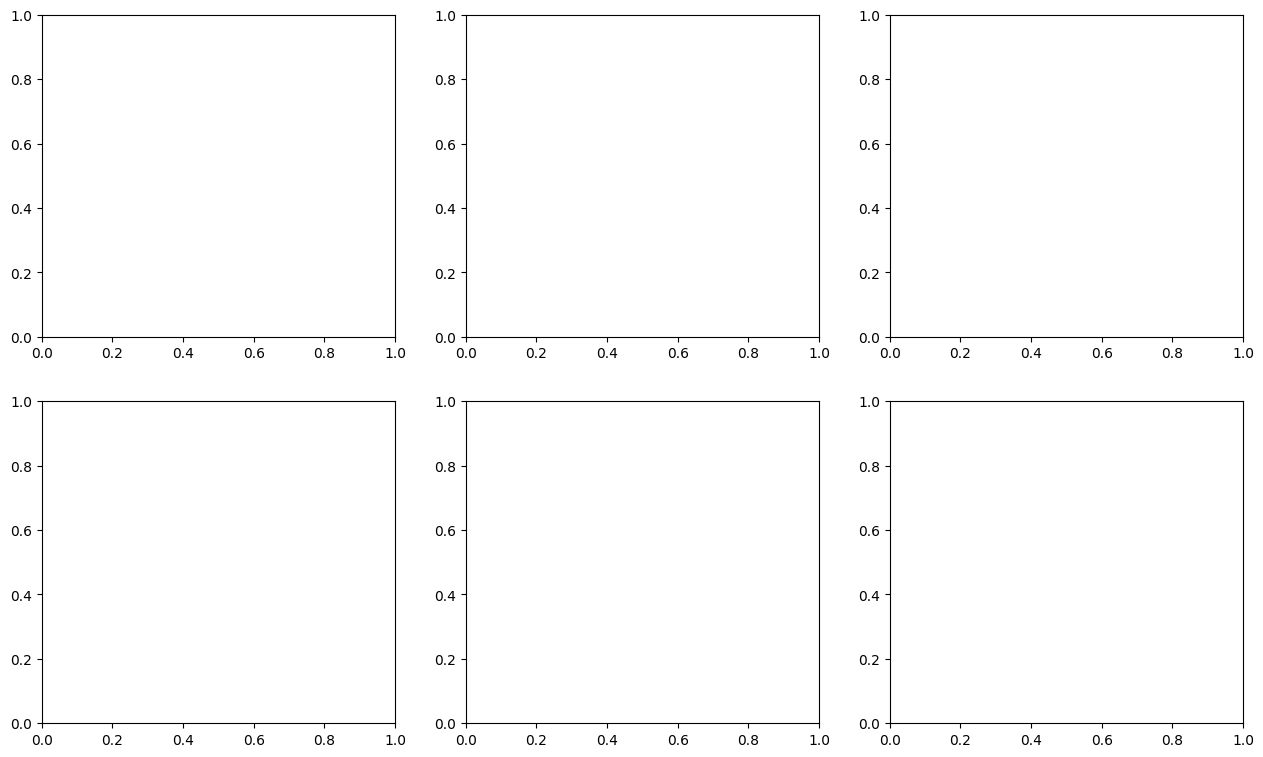

In [3]:
# BRASIL INTEIRO: forca e tempo de resposta (SSTA Nino 3.4) por condicao
fig, axes = plt.subplots(2, 3, figsize=(15.5, 9.2))
for j, cond in enumerate(['todas','el_nino','la_nina']):
    sub = best[(best.condicao==cond) & (best.variavel=='nino34_ssta')].set_index('pixel_id').loc[px['pixel_id']]
    sc1 = u.pixel_map(axes[0,j], px, sub['r_no_best_lag'].values, cmap='BrBG', vmin=-.6, vmax=.6,
                      title=f"r no melhor lag | {cond}")
    sc2 = u.pixel_map(axes[1,j], px, sub['best_lag_sem'].values, cmap='viridis', vmin=0, vmax=52,
                      title=f"melhor lag (sem) | {cond}")
fig.colorbar(sc1, ax=axes[0,:], shrink=.8, label='r (SSTA Nino 3.4 -> chuva); verde=umido, marrom=seco')
fig.colorbar(sc2, ax=axes[1,:], shrink=.8, label='lag do |r| maximo FDR-significativo (semanas)')
fig.suptitle('4C - Brasil inteiro: sinal ENSO -> chuva pixel-a-pixel (SSTA Nino 3.4)')
u.stamp_caption(fig, variavel='r pixel-a-pixel e lag otimo; SSTA Nino 3.4 -> anomalia padronizada CHIRPS', area='Brasil 0.25; caixas NEB e SUL tracejadas', periodo='1981-2026 semanal', fonte='CHIRPS, OISST', extra='FDR BH alfa=0.10 com N_eff Bretherton')
u.save_fig(fig, 'phase4C_mapas_brasil.png')
plt.show()

# tabela-resposta: em quantas semanas o sinal atua no NEB e no Sul, por tipo de sinal
rows = []
for reg, box in u.REGIOES.items():
    m_reg = u.region_mask(px, box)
    for cond in COND:
        for v in u.PACIFIC_VARS:
            sub = best[(best.condicao==cond) & (best.variavel==v)]
            bl = sub.loc[m_reg, 'best_lag_sem'].dropna()
            rr = sub.loc[m_reg, 'r_no_best_lag'].dropna()
            base = {'regiao': reg, 'condicao': cond, 'variavel': v, 'pixels_sig': int(len(bl)),
                    'frac_area_sig_%': round(100*len(bl)/int(m_reg.sum()),1)}
            if len(bl) >= 20:
                base.update({'lag_mediano_sem': float(bl.median()), 'lag_p25_sem': float(bl.quantile(.25)),
                             'lag_p75_sem': float(bl.quantile(.75)), 'r_mediano': float(rr.median()),
                             'sinal_dominante': 'umido' if rr.median()>0 else 'seco'})
            rows.append(base)
resp = pd.DataFrame(rows)
u.save_table(resp, 'phase4C_lag_resposta_neb_sul.csv', index=False)
print(resp[resp.condicao!='todas'].dropna(subset=['lag_mediano_sem'] if 'lag_mediano_sem' in resp else None).to_string(index=False))

In [4]:
# RECORTE NEB: detalhe regional (mapas ampliados + tabela por variavel)
reg = 'NEB'
box = u.REGIOES[reg]
zoom = {'lat_min': box['lat_min']-2, 'lat_max': box['lat_max']+2, 'lon_min': box['lon_min']-2, 'lon_max': box['lon_max']+2}
m_reg = u.region_mask(px, box)
fig, axes = plt.subplots(2, 2, figsize=(12.8, 10.5))
for j, cond in enumerate(['el_nino','la_nina']):
    sub = best[(best.condicao==cond) & (best.variavel=='nino34_ssta')].set_index('pixel_id').loc[px['pixel_id']]
    sc1 = u.pixel_map(axes[0,j], px, sub['r_no_best_lag'].values, cmap='BrBG', vmin=-.6, vmax=.6,
                      title=f"{reg} | r no melhor lag | {cond}", extent=zoom, point_size=14)
    sc2 = u.pixel_map(axes[1,j], px, sub['best_lag_sem'].values, cmap='viridis', vmin=0, vmax=52,
                      title=f"{reg} | melhor lag (sem) | {cond}", extent=zoom, point_size=14)
fig.colorbar(sc1, ax=axes[0,:], shrink=.8, label='r (SSTA Nino 3.4 -> chuva)')
fig.colorbar(sc2, ax=axes[1,:], shrink=.8, label='lag otimo (semanas)')
fig.suptitle(f'4C - Recorte {reg}: distribuicao espacial do sinal e do tempo de resposta')
u.stamp_caption(fig, variavel='r e lag otimo por pixel (SSTA Nino 3.4)', area=f'{reg} (caixa tracejada) + margem de 2 graus', periodo='1981-2026', fonte='CHIRPS, OISST', extra='detalhe regional do atlas phase4C_atlas_pixel.zarr')
u.save_fig(fig, f'phase4C_recorte_{reg}.png')
plt.show()
print(f'--- {reg}: resumo por variavel (condicoes EN/LN) ---')
print(resp[(resp.regiao==reg) & (resp.condicao!='todas')].to_string(index=False))

NameError: name 'px' is not defined

In [5]:
# RECORTE SUL: detalhe regional (mapas ampliados + tabela por variavel)
reg = 'SUL'
box = u.REGIOES[reg]
zoom = {'lat_min': box['lat_min']-2, 'lat_max': box['lat_max']+2, 'lon_min': box['lon_min']-2, 'lon_max': box['lon_max']+2}
m_reg = u.region_mask(px, box)
fig, axes = plt.subplots(2, 2, figsize=(12.8, 10.5))
for j, cond in enumerate(['el_nino','la_nina']):
    sub = best[(best.condicao==cond) & (best.variavel=='nino34_ssta')].set_index('pixel_id').loc[px['pixel_id']]
    sc1 = u.pixel_map(axes[0,j], px, sub['r_no_best_lag'].values, cmap='BrBG', vmin=-.6, vmax=.6,
                      title=f"{reg} | r no melhor lag | {cond}", extent=zoom, point_size=14)
    sc2 = u.pixel_map(axes[1,j], px, sub['best_lag_sem'].values, cmap='viridis', vmin=0, vmax=52,
                      title=f"{reg} | melhor lag (sem) | {cond}", extent=zoom, point_size=14)
fig.colorbar(sc1, ax=axes[0,:], shrink=.8, label='r (SSTA Nino 3.4 -> chuva)')
fig.colorbar(sc2, ax=axes[1,:], shrink=.8, label='lag otimo (semanas)')
fig.suptitle(f'4C - Recorte {reg}: distribuicao espacial do sinal e do tempo de resposta')
u.stamp_caption(fig, variavel='r e lag otimo por pixel (SSTA Nino 3.4)', area=f'{reg} (caixa tracejada) + margem de 2 graus', periodo='1981-2026', fonte='CHIRPS, OISST', extra='detalhe regional do atlas phase4C_atlas_pixel.zarr')
u.save_fig(fig, f'phase4C_recorte_{reg}.png')
plt.show()
print(f'--- {reg}: resumo por variavel (condicoes EN/LN) ---')
print(resp[(resp.regiao==reg) & (resp.condicao!='todas')].to_string(index=False))

NameError: name 'px' is not defined

NameError: name 'px' is not defined

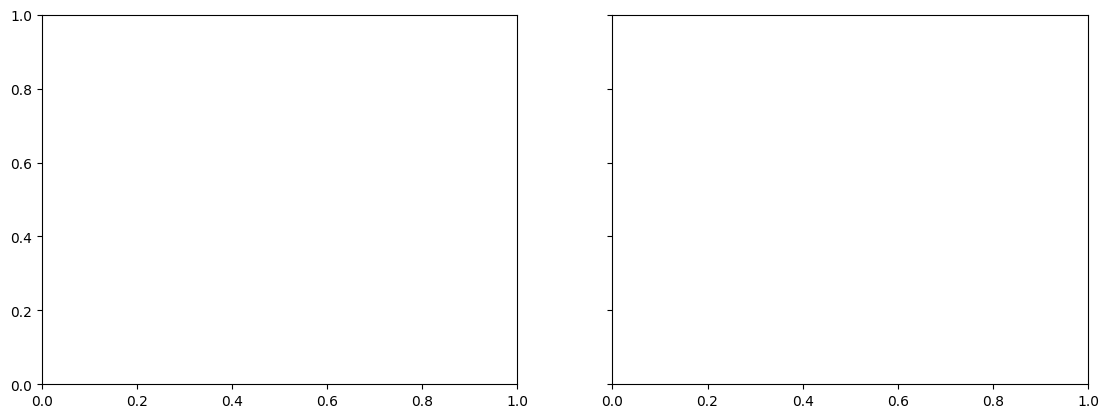

In [6]:
# distribuicao dos lags de resposta: NEB vs SUL, EN vs LN
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=True)
for ax, reg in zip(axes, ['NEB','SUL']):
    m_reg = u.region_mask(px, u.REGIOES[reg])
    for cond, cor in [('el_nino','#b91c1c'), ('la_nina','#1d4ed8')]:
        sub = best[(best.condicao==cond) & (best.variavel=='nino34_ssta')]
        bl = sub.loc[m_reg, 'best_lag_sem'].dropna()
        if len(bl):
            ax.hist(bl, bins=np.arange(0, 80, 4), alpha=.55, color=cor, label=f"{cond} (mediana {bl.median():.0f} sem)", density=True)
    ax.set_title(f'{reg}: distribuicao do lag de resposta (pixels FDR-sig)', fontsize=10)
    ax.set_xlabel('lag (semanas)'); ax.grid(alpha=.25); ax.legend(fontsize=8)
axes[0].set_ylabel('densidade de pixels')
u.stamp_caption(fig, variavel='lag otimo por pixel (SSTA Nino 3.4 -> chuva)', area='caixas NEB e SUL', periodo='1981-2026', fonte='CHIRPS, OISST', extra='responde: quantas semanas o sinal demora a atuar em cada regiao, por tipo de sinal')
u.save_fig(fig, 'phase4C_lags_neb_sul.png')
plt.show()

**Leitura do 4C.** A organizacao segue a ordem pedida: primeiro a distribuicao pixelizada do sinal para o Brasil inteiro (atlas auditavel com N_eff+FDR), depois o detalhe do recorte NEB e do recorte Sul, com mapas ampliados, resumo por variavel e distribuicao dos lags. A resposta central - quantas semanas o sinal do El Nino (e da La Nina) demora para atuar nas chuvas de cada regiao - esta em `phase4C_lag_resposta_neb_sul.csv` e nos histogramas. A clusterizacao dos alvos so acontece em 4D, depois desta distribuicao pixelizada.